# Titanic train

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv('titanic_train.csv')

In [8]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Gender        0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df=df.drop('Name',axis=1)

In [17]:
df=df.drop('Gender',axis=1)

In [18]:
df=df.drop('Ticket',axis=1)

In [21]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,22.0,1,0,7.2500,NaN,S
1,1,1,38.0,1,0,71.2833,C85,C
2,1,3,26.0,0,0,7.9250,NaN,S
3,1,1,35.0,1,0,53.1000,C123,S
4,0,3,35.0,0,0,8.0500,NaN,S


In [22]:
df=df.drop('Cabin',axis=1)

In [23]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [25]:
df["Embarked"] = df["Embarked"].fillna(df ["Embarked"] .mode()[0])


In [27]:
df["Age"] = df["Age"].fillna(df ["Age"].median())

In [28]:
df.isnull().sum()

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [30]:
original_df = pd.read_csv("titanic_train.csv")

df["Gender"] = original_df["Gender"]

In [31]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Gender
0,0,3,22.0,1,0,7.2500,S,male
1,1,1,38.0,1,0,71.2833,C,female
2,1,3,26.0,0,0,7.9250,S,female
3,1,1,35.0,1,0,53.1000,S,female
4,0,3,35.0,0,0,8.0500,S,male
...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,male
887,1,1,19.0,0,0,30.0000,S,female
888,0,3,28.0,1,2,23.4500,S,female
889,1,1,26.0,0,0,30.0000,C,male


Text(0.5, 1.0, 'Age vs Fare')

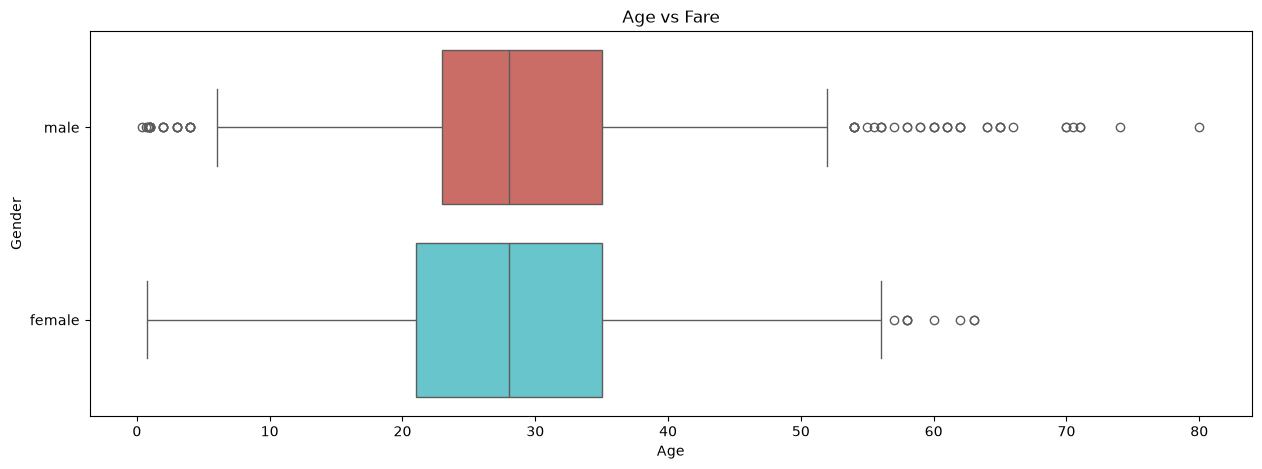

In [42]:
plt.figure(figsize=(15, 5))
sns.boxplot(x='Age', y='Gender', data=df, palette='hls')
plt.title('Age vs Fare')

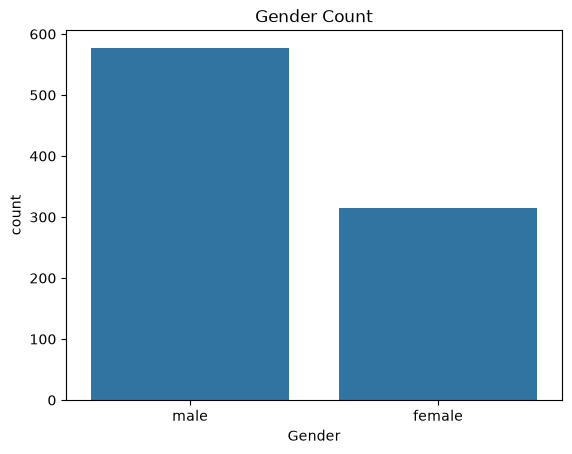

In [36]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Count")
plt.show()

In [37]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
df.nunique()

Survived      2
Pclass        3
Age          88
SibSp         7
Parch         7
Fare        248
Embarked      3
Gender        2
dtype: int64

In [39]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['Embarked', 'Gender'], dtype='str')

Numerical type columns:
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


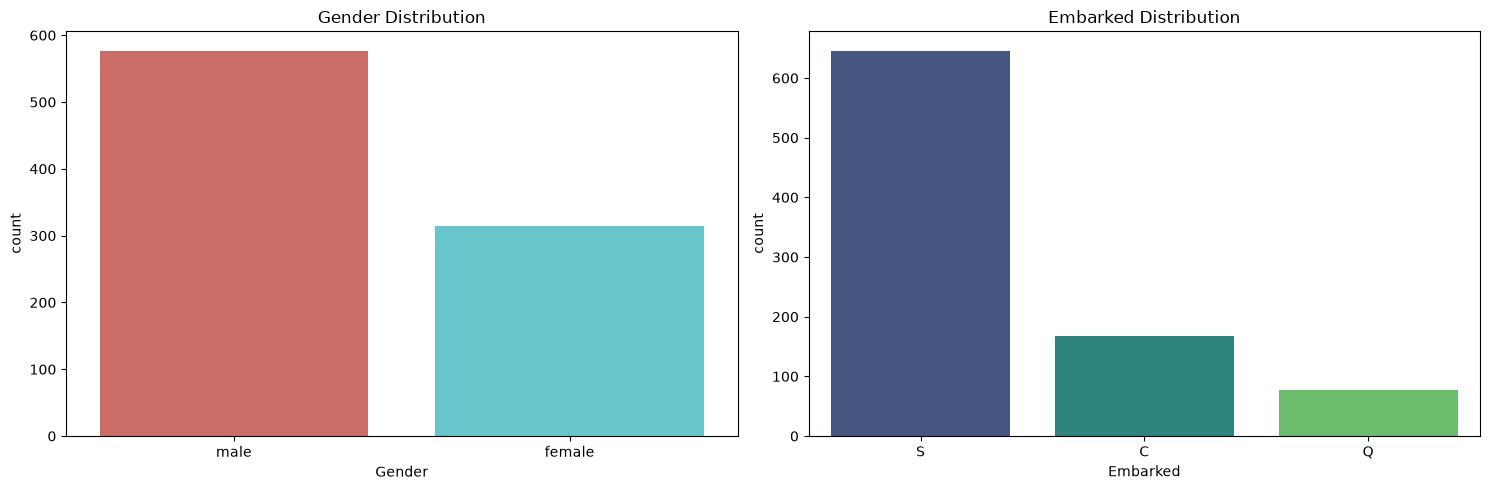

In [40]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df, palette='hls')
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Embarked', data=df, palette='viridis')
plt.title('Embarked Distribution')

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Age vs Fare')

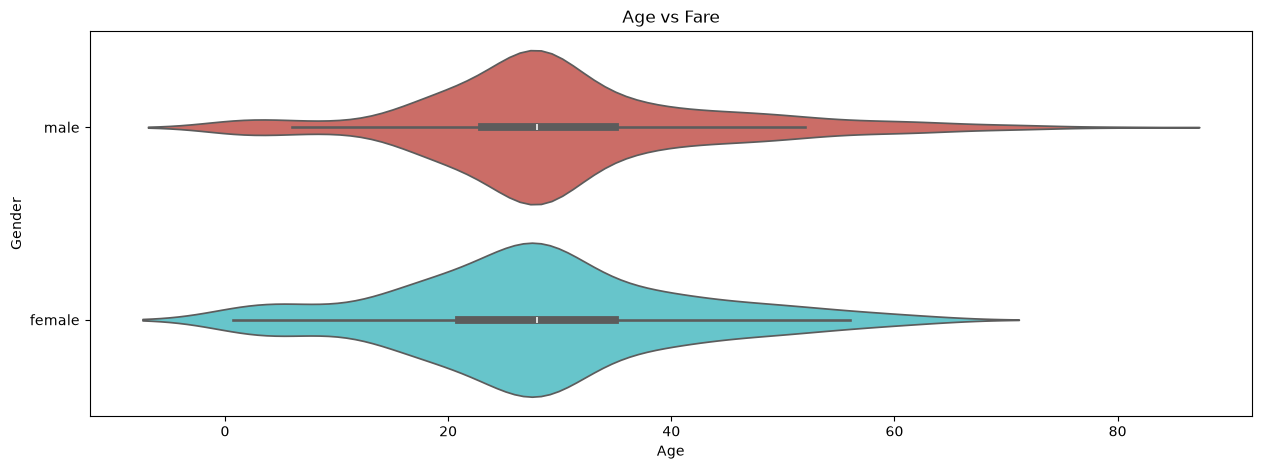

In [43]:
plt.figure(figsize=(15, 5))
sns.violinplot(x='Age', y='Gender', data=df, palette='hls')
plt.title('Age vs Fare')

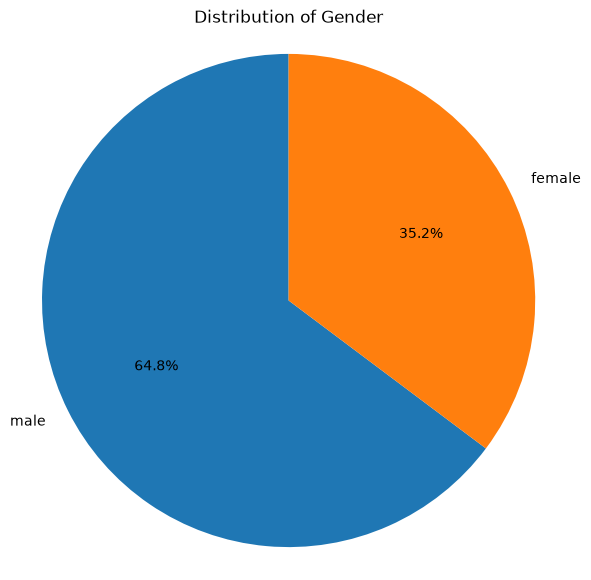

In [48]:
counts = df['Gender'].value_counts()
    
plt.figure(figsize=(7, 7))
plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
)
plt.title(f'Distribution of Gender')
plt.axis('equal')
plt.show()

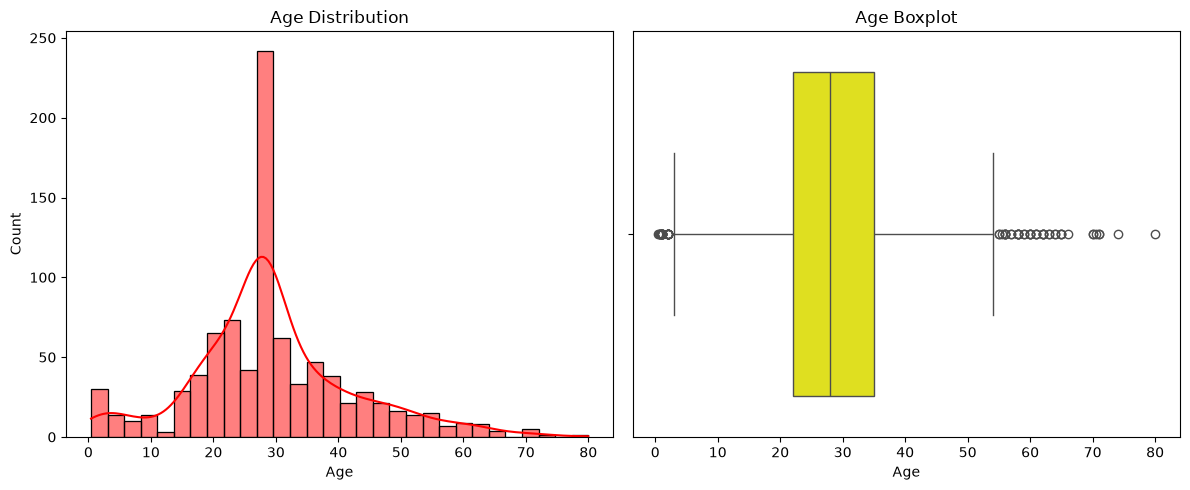

Age Skewness: 0.51


In [54]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='red', bins=30)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], color='yellow')
plt.title('Age Boxplot')

plt.tight_layout()
plt.show()

print("Age Skewness:", round(df['Age'].skew(), 3))

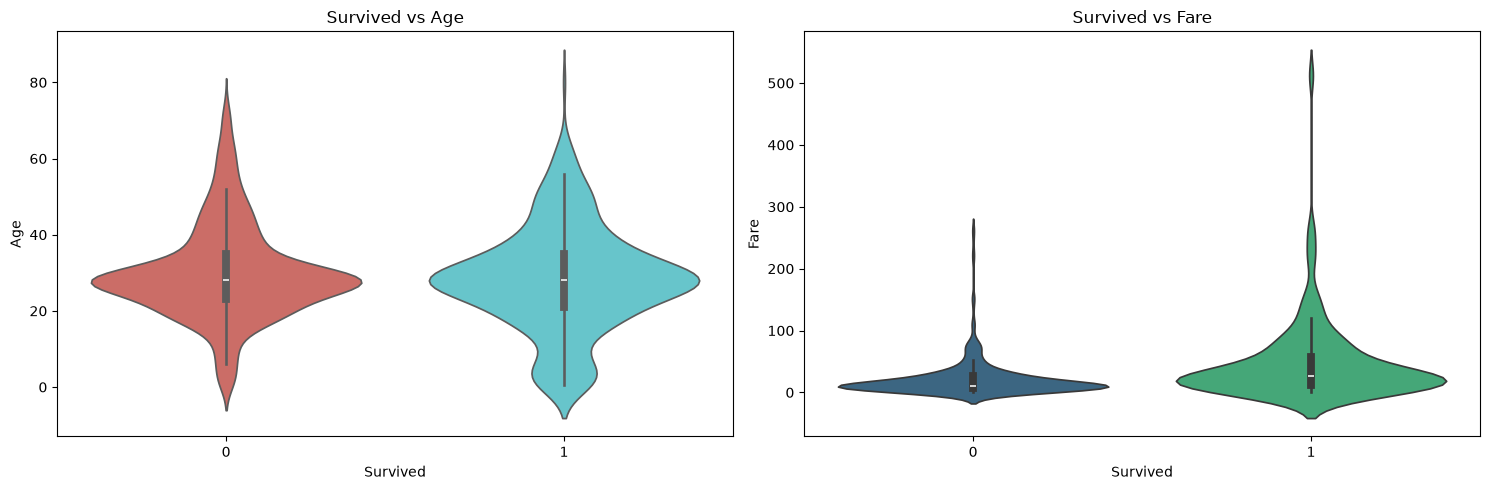

In [57]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='Survived', y='Age', data=df, palette='hls')
plt.title('Survived vs Age')

plt.subplot(1, 2, 2)
sns.violinplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Survived vs Fare')

plt.tight_layout()
plt.show()

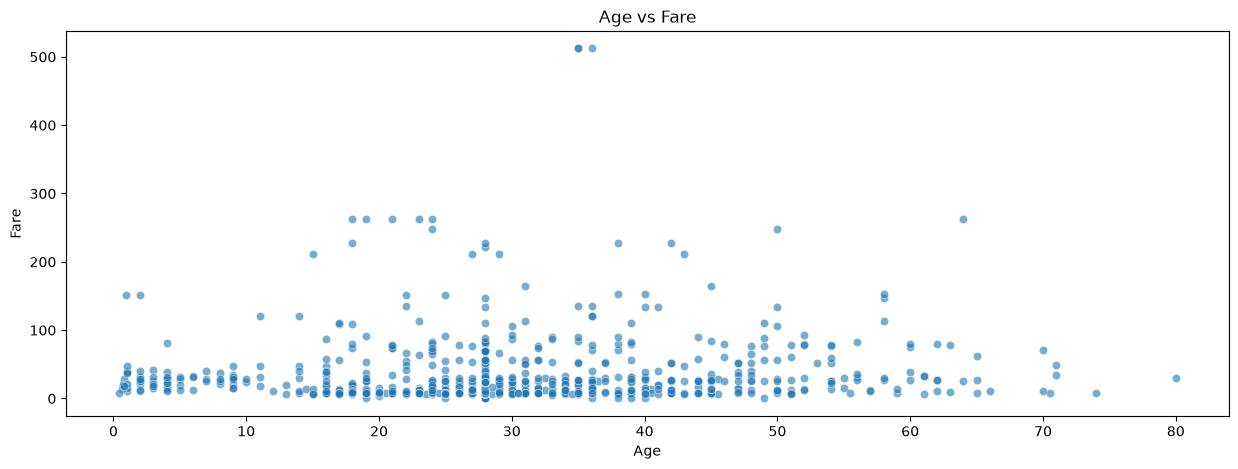

In [58]:
plt.figure(figsize=(15, 5))
sns.scatterplot(x='Age', y="Fare", data=df, alpha=0.6)
plt.title('Age vs Fare')
plt.show()

In [59]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Gender
0,0,3,22.0,1,0,7.2500,S,male
1,1,1,38.0,1,0,71.2833,C,female
2,1,3,26.0,0,0,7.9250,S,female
3,1,1,35.0,1,0,53.1000,S,female
4,0,3,35.0,0,0,8.0500,S,male
...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,male
887,1,1,19.0,0,0,30.0000,S,female
888,0,3,28.0,1,2,23.4500,S,female
889,1,1,26.0,0,0,30.0000,C,male


In [60]:
cat_cols = ['Gender', 'Embarked']

for col in cat_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(col, axis=1)

In [61]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Gender_female,Gender_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,False,True,False,False,True
887,1,1,19.0,0,0,30.0000,True,False,False,False,True
888,0,3,28.0,1,2,23.4500,True,False,False,False,True
889,1,1,26.0,0,0,30.0000,False,True,True,False,False


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [63]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 10)
X_test : (179, 10)
y_train: (712,)
y_test : (179,)


In [64]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [65]:
y_pred=model.predict(X_test)

In [66]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [67]:
print("LR Model Performance:")
print("  Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("  Precision :", round(precision_score(y_test, y_pred), 4))
print("  Recall    :", round(recall_score(y_test, y_pred), 4))
print("  F1 Score  :", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

LR Model Performance:
  Accuracy  : 0.8045
  Precision : 0.7931
  Recall    : 0.6667
  F1 Score  : 0.7244

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

